# PatchEval — Exploratory Data Analysis

This notebook covers 4 EDA levels as defined in `eda.md`:
- **Level 1** — Dataset Overview
- **Level 2** — Vulnerability Characteristics
- **Level 3** — Patch Complexity
- **Level 4** — LLM Repair Difficulty (if benchmark results are available)


## 0. Setup & Load Data

In [1]:
import json
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-darkgrid")
PALETTE = px.colors.qualitative.Bold
sns.set_palette("husl")

DATA_PATH = Path("../patcheval/datasets/patcheval_verified.json")

with DATA_PATH.open() as f:
    raw = json.load(f)

print(f"Total records: {len(raw)}")
print("Sample keys:", list(raw[0].keys()))


Total records: 230
Sample keys: ['cve_id', 'cve_description', 'cwe_info', 'repo', 'patch_url', 'programing_language', 'vul_func', 'fix_func', 'image_url']


In [2]:
# ── Helper functions ───────────────────────────────────────────────────────────

def extract_year(cve_id: str) -> int | None:
    """Extract year from CVE-YYYY-NNNNN format."""
    m = re.match(r"CVE-(\d{4})-", cve_id)
    return int(m.group(1)) if m else None


def count_patch_lines(vul_func: list) -> int:
    """Total number of patch_lines across all vul_func entries."""
    total = 0
    for func in vul_func:
        for loc in func.get("vul_localization", []):
            total += len(loc.get("patch_lines", []))
    return total


def count_patch_hunks(vul_func: list) -> int:
    """Total number of hunks (localization entries) across all vul_func entries."""
    return sum(
        len(func.get("vul_localization", []))
        for func in vul_func
    )


def count_patch_files(vul_func: list) -> int:
    """Number of unique files touched by the patch."""
    return len({func.get("file_path") for func in vul_func})


def patch_complexity(n_lines: int) -> str:
    if n_lines <= 5:
        return "Easy (1–5)"
    elif n_lines <= 20:
        return "Medium (6–20)"
    elif n_lines <= 50:
        return "Hard (21–50)"
    else:
        return "Very Hard (50+)"


# ── Build flat DataFrame ───────────────────────────────────────────────────────
rows = []
for entry in raw:
    cve = entry["cve_id"]
    year = extract_year(cve)
    language = entry.get("programing_language", "Unknown")
    repo = entry.get("repo", "")
    cwes = list(entry.get("cwe_info", {}).keys())  # may be multiple
    vul_func = entry.get("vul_func", [])

    p_lines = count_patch_lines(vul_func)
    p_hunks = count_patch_hunks(vul_func)
    p_files = count_patch_files(vul_func)

    # We expand one row per CWE so cross-tab is easy
    for cwe in (cwes if cwes else ["Unknown"]):
        rows.append({
            "cve_id": cve,
            "year": year,
            "language": language,
            "repo": repo,
            "cwe": cwe,
            "patch_lines": p_lines,
            "patch_hunks": p_hunks,
            "patch_files": p_files,
        })

df_exp = pd.DataFrame(rows)   # expanded (one row per CVE-CWE pair)

# Unique-CVE dataframe (first CWE only, for non-CWE analyses)
df = df_exp.drop_duplicates(subset="cve_id").copy()
df["complexity"] = df["patch_lines"].apply(patch_complexity)
df_exp["complexity"] = df_exp["patch_lines"].apply(patch_complexity)

COMPLEXITY_ORDER = ["Easy (1–5)", "Medium (6–20)", "Hard (21–50)", "Very Hard (50+)"]

print(f"Unique CVEs      : {df['cve_id'].nunique()}")
print(f"Unique repos     : {df['repo'].nunique()}")
print(f"Languages        : {sorted(df['language'].unique())}")
print(f"Unique CWEs      : {df_exp['cwe'].nunique()}")
print(f"Year range       : {int(df['year'].min())} – {int(df['year'].max())}")
df.head(3)


Unique CVEs      : 230
Unique repos     : 175
Languages        : ['Go', 'JavaScript', 'Python']
Unique CWEs      : 41
Year range       : 2015 – 2025


,cve_id,year,language,repo,cwe,patch_lines,patch_hunks,patch_files,complexity
0,CVE-2021-23376,2021,JavaScript,https://github.com/TRomesh/ffmpegdotjs,CWE-78,2,1,1,Easy (1–5)
1,CVE-2020-26215,2020,Python,https://github.com/jupyter/notebook,CWE-601,1,1,1,Easy (1–5)
2,CVE-2022-1986,2022,Go,https://github.com/gogs/gogs,CWE-94,2,2,1,Easy (1–5)


---
## Level 1 — Dataset Overview

In [3]:
# ── Summary statistics ─────────────────────────────────────────────────────────
summary = {
    "# CVEs"        : df["cve_id"].nunique(),
    "# Repositories": df["repo"].nunique(),
    "# Languages"   : df["language"].nunique(),
    "# CWEs"        : df_exp["cwe"].nunique(),
    "Year range"    : f"{int(df['year'].min())} – {int(df['year'].max())}",
}
pd.Series(summary, name="Value").to_frame()


,Value
# CVEs,230
# Repositories,175
# Languages,3
# CWEs,41
Year range,2015 – 2025


In [4]:
# ── Bar chart: CVEs per language ───────────────────────────────────────────────
lang_counts = df["language"].value_counts().reset_index()
lang_counts.columns = ["language", "count"]

fig = px.bar(
    lang_counts, x="language", y="count",
    title="CVEs per Programming Language",
    color="language", color_discrete_sequence=PALETTE,
    text="count",
)
fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False, xaxis_title="Language", yaxis_title="# CVEs")
fig.show()


In [5]:
# ── Bar chart: Top-20 CWE distribution ────────────────────────────────────────
cwe_counts = df_exp["cwe"].value_counts().head(20).reset_index()
cwe_counts.columns = ["cwe", "count"]

fig = px.bar(
    cwe_counts, x="count", y="cwe",
    orientation="h",
    title="Top-20 CWE Distribution",
    color="count",
    color_continuous_scale="Teal",
    text="count",
)
fig.update_layout(yaxis={"autorange": "reversed"}, coloraxis_showscale=False)
fig.show()


In [6]:
# ── Line chart: CVEs per year ──────────────────────────────────────────────────
year_counts = df.dropna(subset=["year"]).groupby("year")["cve_id"].count().reset_index()
year_counts.columns = ["year", "count"]

fig = px.line(
    year_counts, x="year", y="count",
    title="CVE Count by Year",
    markers=True,
    line_shape="spline",
)
fig.update_traces(line_color="#636EFA", marker=dict(size=8))
fig.update_layout(xaxis_title="Year", yaxis_title="# CVEs")
fig.show()


In [7]:
# ── Treemap: CWE → Language ────────────────────────────────────────────────────
# Count CVEs per (CWE, Language) pair
treemap_df = (
    df_exp.groupby(["cwe", "language"])["cve_id"]
    .nunique()
    .reset_index()
    .rename(columns={"cve_id": "count"})
)

# Keep only top-15 CWEs for readability
top_cwes = df_exp["cwe"].value_counts().head(15).index
treemap_df = treemap_df[treemap_df["cwe"].isin(top_cwes)]

fig = px.treemap(
    treemap_df,
    path=["cwe", "language"],
    values="count",
    title="Treemap: CWE → Language (Top 15 CWEs)",
    color="count",
    color_continuous_scale="RdBu",
)
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()


---
## Level 2 — Vulnerability Characteristics

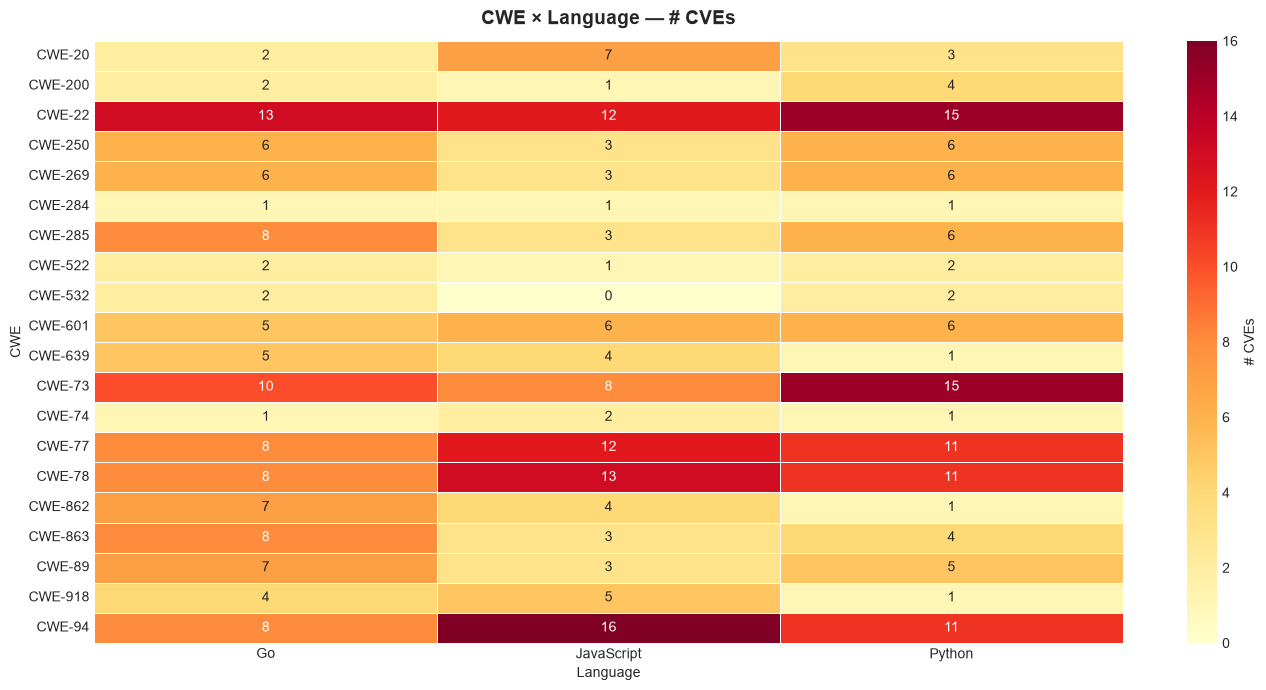

In [8]:
# ── CWE × Language pivot ───────────────────────────────────────────────────────
top_cwes_20  = df_exp["cwe"].value_counts().head(20).index
top_langs    = df_exp["language"].value_counts().head(8).index

pivot_cwe_lang = (
    df_exp[
        df_exp["cwe"].isin(top_cwes_20) & df_exp["language"].isin(top_langs)
    ]
    .groupby(["cwe", "language"])["cve_id"]
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot_cwe_lang, annot=True, fmt="d",
    cmap="YlOrRd", linewidths=0.5, ax=ax,
    cbar_kws={"label": "# CVEs"},
)
ax.set_title("CWE × Language — # CVEs", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Language")
ax.set_ylabel("CWE")
plt.tight_layout()
plt.show()


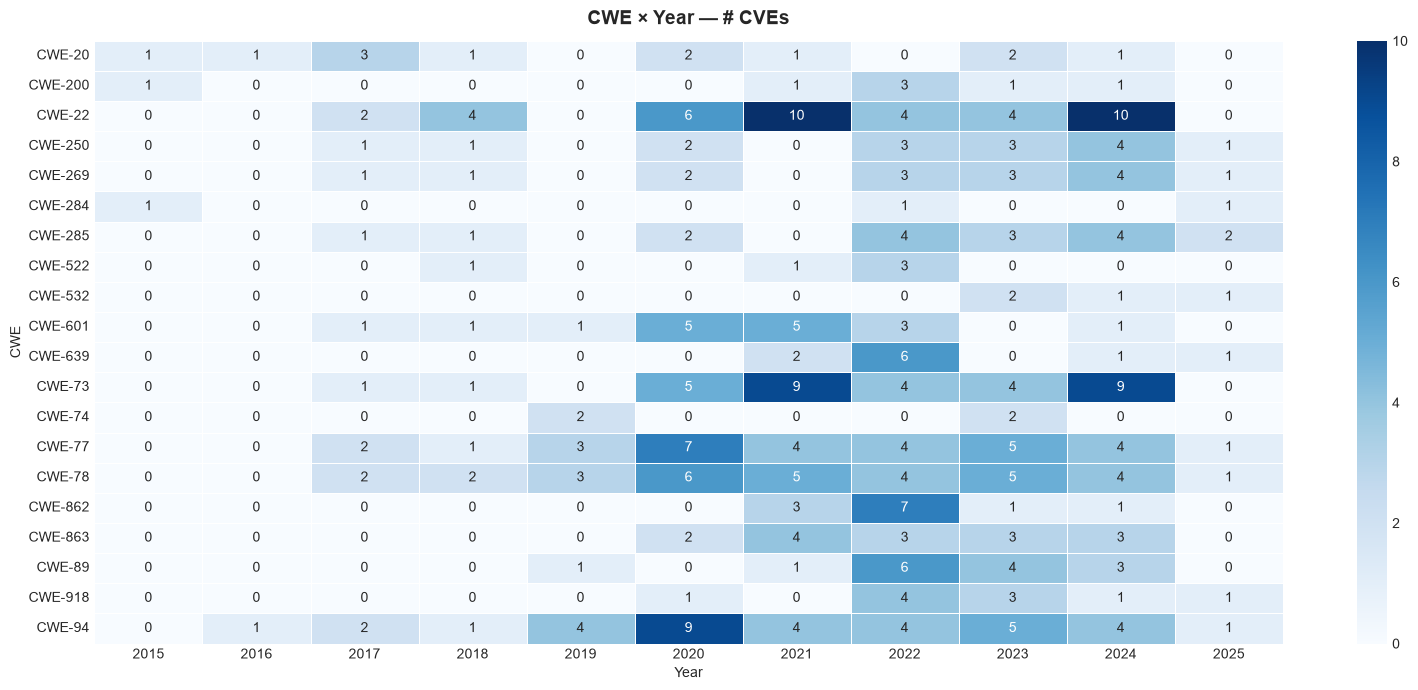

In [9]:
# ── CWE × Year heatmap ────────────────────────────────────────────────────────
pivot_cwe_year = (
    df_exp[
        df_exp["cwe"].isin(top_cwes_20) & df_exp["year"].notna()
    ]
    .groupby(["cwe", "year"])["cve_id"]
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot_cwe_year, annot=True, fmt="d",
    cmap="Blues", linewidths=0.4, ax=ax,
)
ax.set_title("CWE × Year — # CVEs", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("CWE")
plt.tight_layout()
plt.show()


In [10]:
# ── Language × Year grouped bar ────────────────────────────────────────────────
lang_year = (
    df.dropna(subset=["year"])
    .groupby(["year", "language"])["cve_id"]
    .count()
    .reset_index()
    .rename(columns={"cve_id": "count"})
)

fig = px.bar(
    lang_year, x="year", y="count",
    color="language",
    barmode="stack",
    title="Language × Year — CVE Distribution",
    color_discrete_sequence=PALETTE,
)
fig.update_layout(xaxis_title="Year", yaxis_title="# CVEs", legend_title="Language")
fig.show()


---
## Level 3 — Patch Complexity

In [11]:
# ── Descriptive stats for patch metrics ───────────────────────────────────────
df[["patch_lines", "patch_hunks", "patch_files"]].describe().round(2)


,patch_lines,patch_hunks,patch_files
count,230.00,230.00,230.00
mean,4.43,1.83,1.06
std,7.10,1.68,0.23
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,2.00,1.00,1.00
75%,4.00,2.00,1.00
max,63.00,15.00,2.00


In [12]:
# ── Distribution of patch_lines / patch_hunks / patch_files ───────────────────
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=["Patch Lines", "Patch Hunks", "Patch Files"],
)

metrics = ["patch_lines", "patch_hunks", "patch_files"]
colors  = ["#636EFA", "#EF553B", "#00CC96"]

for col_idx, (metric, color) in enumerate(zip(metrics, colors), start=1):
    fig.add_trace(
        go.Histogram(
            x=df[metric],
            marker_color=color,
            name=metric,
            nbinsx=30,
            opacity=0.85,
        ),
        row=1, col=col_idx,
    )

fig.update_layout(
    title_text="Distribution of Patch Complexity Metrics",
    showlegend=False,
    height=400,
)
fig.show()


In [13]:
# ── Complexity tier distribution ───────────────────────────────────────────────
tier_counts = df["complexity"].value_counts().reindex(COMPLEXITY_ORDER).reset_index()
tier_counts.columns = ["complexity", "count"]

fig = px.bar(
    tier_counts, x="complexity", y="count",
    title="Patch Complexity Tier Distribution",
    color="complexity",
    color_discrete_map={
        "Easy (1–5)"    : "#2ecc71",
        "Medium (6–20)" : "#f1c40f",
        "Hard (21–50)"  : "#e67e22",
        "Very Hard (50+)": "#e74c3c",
    },
    text="count",
)
fig.update_traces(textposition="outside")
fig.update_layout(
    showlegend=False,
    xaxis_title="Complexity Tier",
    yaxis_title="# CVEs",
)
fig.show()


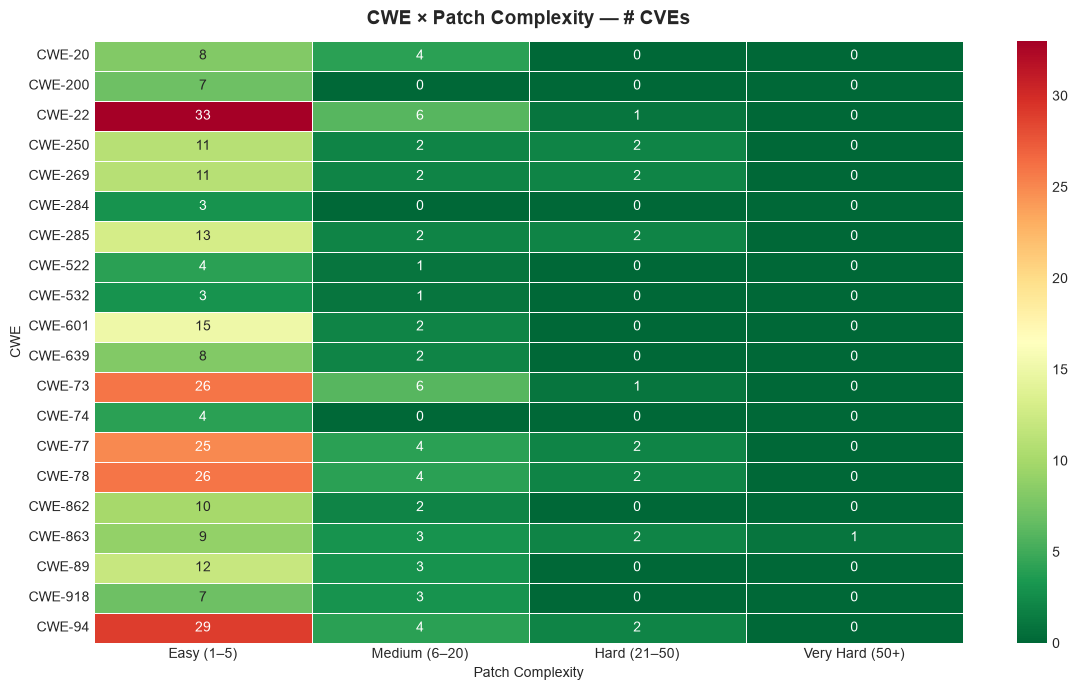

In [14]:
# ── CWE × Patch Complexity cross-tab ──────────────────────────────────────────
pivot_cwe_complexity = (
    df_exp[
        df_exp["cwe"].isin(top_cwes_20)
    ]
    .groupby(["cwe", "complexity"])["cve_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=COMPLEXITY_ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_cwe_complexity, annot=True, fmt="d",
    cmap="RdYlGn_r", linewidths=0.5, ax=ax,
)
ax.set_title("CWE × Patch Complexity — # CVEs", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Patch Complexity")
ax.set_ylabel("CWE")
plt.tight_layout()
plt.show()


In [15]:
# ── Language × Patch Complexity ────────────────────────────────────────────────
lang_complexity = (
    df.groupby(["language", "complexity"])["cve_id"]
    .count()
    .reset_index()
    .rename(columns={"cve_id": "count"})
)
lang_complexity["complexity"] = pd.Categorical(
    lang_complexity["complexity"], categories=COMPLEXITY_ORDER, ordered=True
)
lang_complexity = lang_complexity.sort_values(["language", "complexity"])

fig = px.bar(
    lang_complexity, x="language", y="count",
    color="complexity",
    barmode="group",
    title="Language × Patch Complexity",
    category_orders={"complexity": COMPLEXITY_ORDER},
    color_discrete_map={
        "Easy (1–5)"    : "#2ecc71",
        "Medium (6–20)" : "#f1c40f",
        "Hard (21–50)"  : "#e67e22",
        "Very Hard (50+)": "#e74c3c",
    },
)
fig.update_layout(xaxis_title="Language", yaxis_title="# CVEs", legend_title="Complexity")
fig.show()


In [16]:
# ── Year × Patch Complexity stacked bar ───────────────────────────────────────
year_complexity = (
    df.dropna(subset=["year"])
    .groupby(["year", "complexity"])["cve_id"]
    .count()
    .reset_index()
    .rename(columns={"cve_id": "count"})
)
fig = px.bar(
    year_complexity, x="year", y="count",
    color="complexity",
    barmode="stack",
    title="Year × Patch Complexity",
    category_orders={"complexity": COMPLEXITY_ORDER},
    color_discrete_map={
        "Easy (1–5)"    : "#2ecc71",
        "Medium (6–20)" : "#f1c40f",
        "Hard (21–50)"  : "#e67e22",
        "Very Hard (50+)": "#e74c3c",
    },
)
fig.update_layout(xaxis_title="Year", yaxis_title="# CVEs", legend_title="Complexity")
fig.show()


In [17]:
# ── Box plots: patch_lines per language ───────────────────────────────────────
fig = px.box(
    df, x="language", y="patch_lines",
    color="language",
    title="Patch Lines per Language",
    points="outliers",
    color_discrete_sequence=PALETTE,
)
fig.update_layout(showlegend=False, yaxis_title="Patch Lines")
fig.show()


In [18]:
# ── Scatter: patch_lines vs patch_hunks, colored by language ──────────────────
fig = px.scatter(
    df, x="patch_lines", y="patch_hunks",
    color="language",
    size="patch_files",
    hover_name="cve_id",
    title="Patch Lines vs Hunks (bubble size = # files changed)",
    color_discrete_sequence=PALETTE,
    opacity=0.7,
)
fig.update_layout(xaxis_title="Patch Lines", yaxis_title="Patch Hunks")
fig.show()


---
## Level 4 — LLM Repair Difficulty

> **Note:** This section requires benchmark results (e.g., from a LLM evaluation run).  
> The cells below show the analysis structure — replace `llm_results.json` with your actual result file.
> If no benchmark results are available yet, skip this section.


In [19]:
# ── Load LLM benchmark results (example structure) ────────────────────────────
#
# Expected format:
# [
#   {"cve_id": "CVE-2021-XXXX", "model": "gpt-4o", "success": true/false},
#   ...
# ]
#
# Adjust the path to your actual results file:

LLM_RESULTS_PATH = Path("../patcheval/results/llm_results.json")  # ← change me

if LLM_RESULTS_PATH.exists():
    with LLM_RESULTS_PATH.open() as f:
        llm_raw = json.load(f)

    df_llm = pd.DataFrame(llm_raw)
    # Merge with patch metadata
    df_llm = df_llm.merge(
        df[["cve_id", "language", "cwe", "patch_lines", "patch_hunks", "patch_files", "complexity", "year"]],
        on="cve_id", how="left",
    )
    print(f"LLM results loaded: {len(df_llm)} rows, {df_llm['cve_id'].nunique()} CVEs")
    print(f"Models            : {df_llm['model'].unique()}")
    df_llm.head(3)
else:
    print("⚠️  LLM results file not found. Generating synthetic demo data for structure illustration.")

    rng = np.random.default_rng(42)
    sample_cves = df["cve_id"].sample(min(80, len(df)), random_state=42).values
    models = ["gpt-4o", "claude-3-5-sonnet", "gemini-1.5-pro"]

    demo_rows = []
    for cve in sample_cves:
        n_lines = df.loc[df["cve_id"] == cve, "patch_lines"].values[0]
        base_prob = max(0.1, 0.9 - n_lines * 0.01)  # harder patch → lower success
        for model in models:
            demo_rows.append({
                "cve_id" : cve,
                "model"  : model,
                "success": bool(rng.random() < base_prob),
            })

    df_llm = pd.DataFrame(demo_rows)
    df_llm = df_llm.merge(
        df[["cve_id", "language", "cwe", "patch_lines", "patch_hunks", "patch_files", "complexity", "year"]],
        on="cve_id", how="left",
    )
    print("Demo data created. Replace with real benchmark results.")
    df_llm.head(3)


⚠️  LLM results file not found. Generating synthetic demo data for structure illustration.
Demo data created. Replace with real benchmark results.


In [20]:
# ── P(repair success | language) ──────────────────────────────────────────────
success_lang = (
    df_llm.groupby(["model", "language"])["success"]
    .mean()
    .reset_index()
    .rename(columns={"success": "success_rate"})
)

fig = px.bar(
    success_lang, x="language", y="success_rate",
    color="model",
    barmode="group",
    title="P(repair success | Language) per Model",
    color_discrete_sequence=PALETTE,
)
fig.update_layout(
    yaxis_tickformat=".0%",
    xaxis_title="Language",
    yaxis_title="Success Rate",
    legend_title="Model",
)
fig.show()


In [21]:
# ── P(repair success | Patch Complexity) ──────────────────────────────────────
success_complexity = (
    df_llm.groupby(["model", "complexity"])["success"]
    .mean()
    .reset_index()
    .rename(columns={"success": "success_rate"})
)
success_complexity["complexity"] = pd.Categorical(
    success_complexity["complexity"], categories=COMPLEXITY_ORDER, ordered=True
)
success_complexity = success_complexity.sort_values("complexity")

fig = px.line(
    success_complexity, x="complexity", y="success_rate",
    color="model",
    markers=True,
    title="P(repair success | Patch Complexity) per Model",
    color_discrete_sequence=PALETTE,
    category_orders={"complexity": COMPLEXITY_ORDER},
)
fig.update_layout(
    yaxis_tickformat=".0%",
    xaxis_title="Patch Complexity",
    yaxis_title="Success Rate",
    legend_title="Model",
)
fig.show()


In [22]:
# ── P(repair success | CWE) — top-15 CWEs ─────────────────────────────────────
top_cwes_15  = df_exp["cwe"].value_counts().head(15).index
df_llm_top_cwe = df_llm[df_llm["cwe"].isin(top_cwes_15)]

success_cwe = (
    df_llm_top_cwe.groupby(["model", "cwe"])["success"]
    .mean()
    .reset_index()
    .rename(columns={"success": "success_rate"})
)

fig = px.bar(
    success_cwe, x="success_rate", y="cwe",
    color="model",
    orientation="h",
    barmode="group",
    title="P(repair success | CWE) per Model (Top 15 CWEs)",
    color_discrete_sequence=PALETTE,
)
fig.update_layout(
    xaxis_tickformat=".0%",
    xaxis_title="Success Rate",
    yaxis_title="CWE",
    legend_title="Model",
    height=600,
)
fig.show()


In [23]:
# ── P(repair success | patch_files) ── single vs multi-file ───────────────────
df_llm["multi_file"] = df_llm["patch_files"].apply(
    lambda n: "Multi-file" if n > 1 else "Single-file"
)

success_file = (
    df_llm.groupby(["model", "multi_file"])["success"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "success_rate", "count": "n"})
)

fig = px.bar(
    success_file, x="multi_file", y="success_rate",
    color="model",
    barmode="group",
    title="P(repair success | Single-file vs Multi-file)",
    color_discrete_sequence=PALETTE,
    text=success_file["success_rate"].apply(lambda v: f"{v:.1%}"),
)
fig.update_traces(textposition="outside")
fig.update_layout(
    yaxis_tickformat=".0%",
    xaxis_title="Patch Scope",
    yaxis_title="Success Rate",
    legend_title="Model",
)
fig.show()


In [24]:
# ── Overall model performance summary ─────────────────────────────────────────
overall = (
    df_llm.groupby("model")["success"]
    .agg(["mean", "sum", "count"])
    .reset_index()
    .rename(columns={"mean": "success_rate", "sum": "n_success", "count": "n_total"})
)
overall["success_rate_pct"] = (overall["success_rate"] * 100).round(1)
overall


,model,success_rate,n_success,n_total,success_rate_pct
0,claude-3-5-sonnet,0.825,66,80,82.5
1,gemini-1.5-pro,0.900,72,80,90.0
2,gpt-4o,0.900,72,80,90.0
